# 04 — Two-Tower Model
Separate user and item encoder networks, scored via dot product.
Trained on LastFM-2K (implicit) and also evaluated on MovieLens.
**Requires:** `01_data_preprocessing.ipynb`, `02_baseline.ipynb`, and `03_ncf.ipynb`.

In [1]:
import pandas as pd
import numpy as np

import pickle, time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


ROOT   = Path('..').resolve()
PROC   = ROOT / 'data' / 'processed'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
print(f'Looking for processed data in: {PROC}')

def load_dataset(name):
    p     = PROC / name
    train = pd.read_parquet(p / 'train.parquet')
    val   = pd.read_parquet(p / 'val.parquet')
    test  = pd.read_parquet(p / 'test.parquet')
    meta  = pickle.load(open(p / 'meta.pkl','rb'))
    return train, val, test, meta

ml_train,  ml_val,  ml_test,  ml_meta  = load_dataset('ml-100k')
lastfm_train, lastfm_val, lastfm_test, lastfm_meta = load_dataset('lastfm-2k')
n_users_ml,   n_items_ml   = ml_meta['n_users'],   ml_meta['n_items']
n_users_lastfm, n_items_lastfm = lastfm_meta['n_users'], lastfm_meta['n_items']
print(f'MovieLens:   {n_users_ml:,} users, {n_items_ml:,} items')
print(f'LastFM-2K:   {n_users_lastfm:,} users, {n_items_lastfm:,} items')

Using device: cpu
Looking for processed data in: /Users/XuanNguyen/Documents/NUS/DSS5104/dss5104_recommendation_system/data/processed
MovieLens:   938 users, 1,008 items
LastFM-2K:   1,859 users, 2,823 items


## Evaluation metrics

In [2]:
def hit_rate_at_k(recs, gt, k=10):
    hits, total = 0, 0
    for u, r in recs.items():
        g = set(gt.get(u, []))
        if not g: continue
        hits += int(len(set(r[:k]) & g) > 0); total += 1
    return hits / total if total else 0.0

def ndcg_at_k(recs, gt, k=10):
    scores = []
    for u, r in recs.items():
        g = set(gt.get(u, []))
        if not g: continue
        dcg  = sum(1/np.log2(i+2) for i,it in enumerate(r[:k]) if it in g)
        idcg = sum(1/np.log2(i+2) for i in range(min(len(g),k)))
        scores.append(dcg/idcg if idcg else 0.0)
    return float(np.mean(scores)) if scores else 0.0

def map_at_k(recs, gt, k=10):
    aps = []
    for u, r in recs.items():
        g = set(gt.get(u, []))
        if not g: continue
        hits, ps = 0, 0.0
        for rank, it in enumerate(r[:k]):
            if it in g: hits += 1; ps += hits/(rank+1)
        aps.append(ps / min(len(g),k))
    return float(np.mean(aps)) if aps else 0.0

def all_metrics(recs, gt, k=10):
    return {f'hr@{k}': hit_rate_at_k(recs,gt,k),
            f'ndcg@{k}': ndcg_at_k(recs,gt,k),
            f'map@{k}':  map_at_k(recs,gt,k)}

def cold_start_metrics(recs, test_df, k=10):
    gt_all  = test_df.groupby('user_id')['item_id'].apply(list).to_dict()
    cold    = set(test_df[test_df.cold_start==True].user_id)
    regular = set(test_df[test_df.cold_start==False].user_id)
    return {
        'cold_start': all_metrics({u:r for u,r in recs.items() if u in cold},
                                   {u:g for u,g in gt_all.items() if u in cold}, k),
        'regular':    all_metrics({u:r for u,r in recs.items() if u in regular},
                                   {u:g for u,g in gt_all.items() if u in regular}, k),
    }
print('Metrics defined.')

Metrics defined.


## Dataset

In [3]:
class ImplicitDataset(Dataset):
    """Positive + n_neg randomly sampled negative items per interaction."""
    def __init__(self, df, n_items, n_neg=4):
        self.users    = df['user_id'].values
        self.items    = df['item_id'].values
        self.n_items  = n_items
        self.n_neg    = n_neg
        self.user_pos = df.groupby('user_id')['item_id'].apply(set).to_dict()

    def __len__(self):
        return len(self.users) * (1 + self.n_neg)

    def __getitem__(self, idx):
        pos_idx = idx // (1 + self.n_neg)
        is_neg  = (idx % (1 + self.n_neg)) != 0
        user    = self.users[pos_idx]
        if not is_neg:
            return (torch.tensor(user, dtype=torch.long),
                    torch.tensor(self.items[pos_idx], dtype=torch.long),
                    torch.tensor(1.0))
        pos = self.user_pos.get(user, set())
        while True:
            neg = np.random.randint(0, self.n_items)
            if neg not in pos: break
        return (torch.tensor(user, dtype=torch.long),
                torch.tensor(neg, dtype=torch.long),
                torch.tensor(0.0))

print('ImplicitDataset defined.')

ImplicitDataset defined.


## Two-tower model

In [4]:
def _build_tower(input_dim, hidden_dims, dropout):
    layers, in_dim = [], input_dim
    for out_dim in hidden_dims:
        layers += [nn.Linear(in_dim, out_dim), nn.ReLU(), nn.Dropout(dropout)]
        in_dim = out_dim
    return nn.Sequential(*layers)


class TwoTower(nn.Module):
    """
    Two-tower retrieval model.

    User and item each have their own embedding + MLP tower.
    The towers NEVER share weights or exchange activations.
    This independence allows offline pre-computation of all item embeddings
    and fast ANN retrieval at serving time.

    Score = cosine similarity after L2 normalisation.
    """
    def __init__(self, n_users, n_items, embed_dim=64,
                 tower_dims=(128, 64), dropout=0.2):
        super().__init__()
        self.user_emb   = nn.Embedding(n_users, embed_dim)
        self.item_emb   = nn.Embedding(n_items, embed_dim)
        self.user_tower = _build_tower(embed_dim, tower_dims, dropout)
        self.item_tower = _build_tower(embed_dim, tower_dims, dropout)
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def encode_user(self, user_ids):
        """L2-normalised user vector. Run this at serving time."""
        return F.normalize(self.user_tower(self.user_emb(user_ids)), dim=-1)

    def encode_item(self, item_ids):
        """L2-normalised item vector. Pre-compute and cache these offline."""
        return F.normalize(self.item_tower(self.item_emb(item_ids)), dim=-1)

    def forward(self, user_ids, item_ids):
        u = self.encode_user(user_ids)
        v = self.encode_item(item_ids)
        return (u * v).sum(dim=-1)   # cosine similarity (vectors already normalised)

print('TwoTower model defined.')

TwoTower model defined.


## Training loop

In [5]:
def evaluate_two_tower(model, val_df, n_items, k=10, n_neg_eval=99, device='cpu'):
    model.eval()
    user_pos = val_df.groupby('user_id')['item_id'].apply(set).to_dict()
    recs, gt = {}, {}

    # Pre-compute all item embeddings once (the key efficiency advantage)
    all_items_t  = torch.arange(n_items, dtype=torch.long).to(device)
    with torch.no_grad():
        all_item_embs = model.encode_item(all_items_t)  # (n_items, d)

    with torch.no_grad():
        for uid, pos_items in user_pos.items():
            pos_list = list(pos_items)
            negs = []
            while len(negs) < n_neg_eval:
                neg = np.random.randint(0, n_items)
                if neg not in pos_items: negs.append(neg)
            candidates  = pos_list + negs
            u_vec       = model.encode_user(
                torch.tensor([uid], dtype=torch.long).to(device))  # (1, d)
            cand_embs   = all_item_embs[candidates]                 # (C, d)
            scores      = (u_vec * cand_embs).sum(dim=-1).cpu().numpy()
            top_k       = np.argsort(scores)[::-1][:k]
            recs[uid]   = [candidates[i] for i in top_k]
            gt[uid]     = pos_list
    return all_metrics(recs, gt, k)


def train_two_tower(model, train_df, val_df, n_items,
                    n_epochs=30, batch_size=1024, lr=1e-3,
                    n_neg=4, patience=5, device='cpu'):
    dataset   = ImplicitDataset(train_df, n_items, n_neg=n_neg)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=2, factor=0.5)

    best_ndcg, best_state, no_improve = 0.0, None, 0
    history = []

    for epoch in range(1, n_epochs+1):
        model.train()
        total_loss = 0.0
        for users, items, labels in loader:
            users, items, labels = users.to(device), items.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = F.binary_cross_entropy_with_logits(model(users, items), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        val_m = evaluate_two_tower(model, val_df, n_items, k=10, device=device)
        ndcg  = val_m['ndcg@10']
        scheduler.step(-ndcg)
        history.append({'epoch': epoch, 'loss': total_loss/len(loader), **val_m})
        print(f'Epoch {epoch:3d} | loss {total_loss/len(loader):.4f} | '
              f'HR@10 {val_m["hr@10"]:.4f} | NDCG@10 {ndcg:.4f}')

        if ndcg > best_ndcg:
            best_ndcg  = ndcg
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping at epoch {epoch}')
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

print('Training functions defined.')

Training functions defined.


## Train Two-Tower on LastFM-2K (implicit)

In [6]:
EMBED_DIM   = 64
TOWER_DIMS  = (128, 64)
N_NEG       = 4
LR          = 1e-3
BATCH       = 1024
N_EPOCHS    = 30

tt_lastfm = TwoTower(n_users_lastfm, n_items_lastfm,
                       embed_dim=EMBED_DIM, tower_dims=TOWER_DIMS).to(DEVICE)
total_params_tt = sum(p.numel() for p in tt_lastfm.parameters())
print(f'Two-Tower parameters: {total_params_tt:,}')

t0 = time.time()
tt_lastfm, history_tt_lastfm = train_two_tower(
    tt_lastfm, lastfm_train, lastfm_val, n_items_lastfm,
    n_epochs=N_EPOCHS, batch_size=BATCH, lr=LR,
    n_neg=N_NEG, patience=5, device=DEVICE
)
train_time_tt_lastfm = time.time() - t0
print(f'Training time: {train_time_tt_lastfm:.1f}s')

Two-Tower parameters: 332,800
Epoch   1 | loss 0.6930 | HR@10 0.3790 | NDCG@10 0.1617
Epoch   2 | loss 0.6907 | HR@10 0.3854 | NDCG@10 0.1679
Epoch   3 | loss 0.6903 | HR@10 0.3887 | NDCG@10 0.1701
Epoch   4 | loss 0.6900 | HR@10 0.3844 | NDCG@10 0.1703
Epoch   5 | loss 0.6898 | HR@10 0.3887 | NDCG@10 0.1731
Epoch   6 | loss 0.6897 | HR@10 0.3763 | NDCG@10 0.1680
Epoch   7 | loss 0.6895 | HR@10 0.3704 | NDCG@10 0.1644
Epoch   8 | loss 0.6894 | HR@10 0.3730 | NDCG@10 0.1703
Epoch   9 | loss 0.6893 | HR@10 0.3736 | NDCG@10 0.1677
Epoch  10 | loss 0.6892 | HR@10 0.3725 | NDCG@10 0.1677
Early stopping at epoch 10
Training time: 31.7s


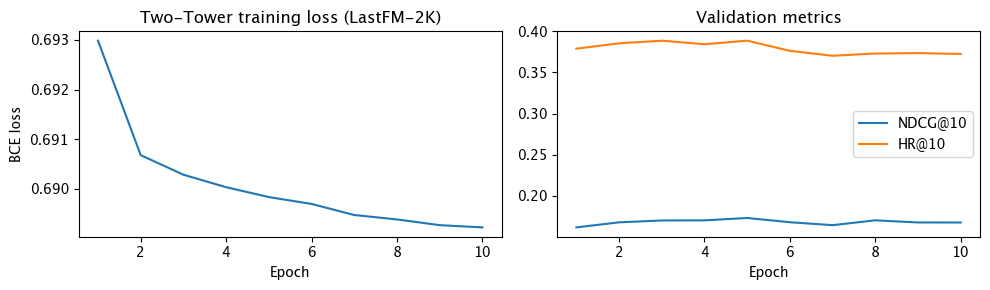

In [7]:
# Training curve
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(history_tt_lastfm.epoch, history_tt_lastfm.loss)
ax1.set_title('Two-Tower training loss (LastFM-2K)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE loss')
ax2.plot(history_tt_lastfm.epoch, history_tt_lastfm['ndcg@10'], label='NDCG@10')
ax2.plot(history_tt_lastfm.epoch, history_tt_lastfm['hr@10'],   label='HR@10')
ax2.set_title('Validation metrics')
ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
PROC.mkdir(parents=True, exist_ok=True)
plt.savefig(PROC / 'two_tower_lastfm_curve.png', dpi=100)
plt.show()

In [8]:
# Evaluate on LastFM-2K test set
gt_lastfm = lastfm_test.groupby('user_id')['item_id'].apply(list).to_dict()

tt_recs_lastfm = {}
tt_lastfm.eval()
all_items_t  = torch.arange(n_items_lastfm, dtype=torch.long).to(DEVICE)
user_seen_lastfm = lastfm_train.groupby('user_id')['item_id'].apply(set).to_dict()

with torch.no_grad():
    all_item_embs = tt_lastfm.encode_item(all_items_t)
    for uid in lastfm_test.user_id.unique():
        u_vec  = tt_lastfm.encode_user(
            torch.tensor([uid], dtype=torch.long).to(DEVICE))
        scores = (u_vec * all_item_embs).sum(dim=-1).cpu().numpy()
        seen   = user_seen_lastfm.get(uid, set())
        scores[list(seen)] = -np.inf
        top_k  = np.argsort(scores)[::-1][:10]
        tt_recs_lastfm[uid] = top_k.tolist()

tt_m_lastfm = all_metrics(tt_recs_lastfm, gt_lastfm, k=10)
print('Two-Tower test metrics — LastFM-2K:')
print(tt_m_lastfm)

print('\nCold-start breakdown:')
for group, m in cold_start_metrics(tt_recs_lastfm, lastfm_test).items():
    print(f'  {group}: {m}')

Two-Tower test metrics — LastFM-2K:
{'hr@10': 0.3752021563342318, 'ndcg@10': 0.10019940930777826, 'map@10': 0.05159417561573896}

Cold-start breakdown:
  cold_start: {'hr@10': 0.0, 'ndcg@10': 0.0, 'map@10': 0.0}
  regular: {'hr@10': 0.3762162162162162, 'ndcg@10': 0.10047021852212362, 'map@10': 0.051733619333619335}


## Also train Two-Tower on MovieLens (for direct NCF comparison)

In [9]:
tt_ml = TwoTower(n_users_ml, n_items_ml,
                  embed_dim=EMBED_DIM, tower_dims=TOWER_DIMS).to(DEVICE)

t0 = time.time()
tt_ml, history_tt_ml = train_two_tower(
    tt_ml, ml_train, ml_val, n_items_ml,
    n_epochs=N_EPOCHS, batch_size=BATCH, lr=LR,
    n_neg=N_NEG, patience=5, device=DEVICE
)
train_time_tt_ml = time.time() - t0

gt_ml = ml_test.groupby('user_id')['item_id'].apply(list).to_dict()
tt_recs_ml = {}
tt_ml.eval()
all_items_t   = torch.arange(n_items_ml, dtype=torch.long).to(DEVICE)
user_seen_ml  = ml_train.groupby('user_id')['item_id'].apply(set).to_dict()

with torch.no_grad():
    all_item_embs = tt_ml.encode_item(all_items_t)
    for uid in ml_test.user_id.unique():
        u_vec  = tt_ml.encode_user(
            torch.tensor([uid], dtype=torch.long).to(DEVICE))
        scores = (u_vec * all_item_embs).sum(dim=-1).cpu().numpy()
        seen   = user_seen_ml.get(uid, set())
        scores[list(seen)] = -np.inf
        top_k  = np.argsort(scores)[::-1][:10]
        tt_recs_ml[uid] = top_k.tolist()

tt_m_ml = all_metrics(tt_recs_ml, gt_ml, k=10)
print(f'Two-Tower test metrics — MovieLens 100K:')
print(tt_m_ml)

Epoch   1 | loss 0.6927 | HR@10 0.2120 | NDCG@10 0.0855
Epoch   2 | loss 0.6907 | HR@10 0.2248 | NDCG@10 0.0874
Epoch   3 | loss 0.6907 | HR@10 0.2420 | NDCG@10 0.0910
Epoch   4 | loss 0.6903 | HR@10 0.2355 | NDCG@10 0.0936
Epoch   5 | loss 0.6903 | HR@10 0.2345 | NDCG@10 0.0900
Epoch   6 | loss 0.6901 | HR@10 0.2366 | NDCG@10 0.0921
Epoch   7 | loss 0.6901 | HR@10 0.2602 | NDCG@10 0.0974
Epoch   8 | loss 0.6899 | HR@10 0.2570 | NDCG@10 0.0976
Epoch   9 | loss 0.6897 | HR@10 0.2580 | NDCG@10 0.0992
Epoch  10 | loss 0.6898 | HR@10 0.2570 | NDCG@10 0.0975
Epoch  11 | loss 0.6897 | HR@10 0.2570 | NDCG@10 0.0972
Epoch  12 | loss 0.6896 | HR@10 0.2527 | NDCG@10 0.0937
Epoch  13 | loss 0.6895 | HR@10 0.2527 | NDCG@10 0.0962
Epoch  14 | loss 0.6896 | HR@10 0.2527 | NDCG@10 0.0929
Early stopping at epoch 14
Two-Tower test metrics — MovieLens 100K:
{'hr@10': 0.22483940042826553, 'ndcg@10': 0.04667908864473662, 'map@10': 0.02185908469978522}


In [11]:
# Save models
torch.save(tt_lastfm.state_dict(), PROC / 'two_tower_lastfm.pt')
torch.save(tt_ml.state_dict(),  PROC / 'two_tower_movielens.pt')

# Final consolidated results table across all notebooks
baseline_config = pickle.load(open(PROC / 'baseline_config.pkl', 'rb'))
ncf_results     = pickle.load(open(PROC / 'ncf_results.pkl', 'rb'))
ncf_results_lastfm = pickle.load(open(PROC / 'ncf_results_lastfm.pkl', 'rb'))

final_summary = pd.DataFrame([
    # MovieLens
    {'Dataset':'MovieLens 100K', 'Model':'Popularity',
     **baseline_config['baseline_metrics']['movielens_popularity']},
    {'Dataset':'MovieLens 100K', 'Model':'SVD',
     **baseline_config['baseline_metrics']['movielens_svd']},
    {'Dataset':'MovieLens 100K', 'Model':'NCF',
     **ncf_results['test_metrics']},
    {'Dataset':'MovieLens 100K', 'Model':'Two-Tower',
     **tt_m_ml},
    # LastFM-2K
    {'Dataset':'LastFM-2K', 'Model':'Popularity',
     **baseline_config['baseline_metrics']['lastfm_popularity']},
    {'Dataset':'LastFM-2K', 'Model':'ALS',
     **baseline_config['baseline_metrics']['lastfm_als']},
    {'Dataset':'LastFM-2K', 'Model':'NCF',
     **ncf_results_lastfm['test_metrics']},
    {'Dataset':'LastFM-2K', 'Model':'Two-Tower',
     **tt_m_lastfm},
]).round(4)

final_summary.to_csv(PROC / 'final_results.csv', index=False)
print('Final results saved to data/processed/final_results.csv')
final_summary

Final results saved to data/processed/final_results.csv


,Dataset,Model,hr@10,ndcg@10,map@10
0,MovieLens 100K,Popularity,0.2505,0.0533,0.0258
1,MovieLens 100K,SVD,0.0535,0.0055,0.0015
2,MovieLens 100K,NCF,0.3405,0.0784,0.0378
3,MovieLens 100K,Two-Tower,0.2248,0.0467,0.0219
4,LastFM-2K,Popularity,0.3423,0.1024,0.0568
5,LastFM-2K,ALS,0.7197,0.2398,0.1387
6,LastFM-2K,NCF,0.6647,0.1903,0.1010
7,LastFM-2K,Two-Tower,0.3752,0.1002,0.0516


In [12]:
# Training time comparison (for report scalability section)
tt_time_table = pd.DataFrame([
    {'Model':'NCF',       'Dataset':'MovieLens 100K',
     'train_time_s': ncf_results['train_time_secs'],
     'n_params':     ncf_results['n_params']},
    {'Model':'NCF',       'Dataset':'LastFM-2K',
     'train_time_s': ncf_results_lastfm['train_time_secs'],
     'n_params':     ncf_results_lastfm['n_params']},
    {'Model':'Two-Tower', 'Dataset':'MovieLens 100K',
     'train_time_s': train_time_tt_ml,
     'n_params':     total_params_tt},
    {'Model':'Two-Tower', 'Dataset':'LastFM-2K',
     'train_time_s': train_time_tt_lastfm,
     'n_params':     total_params_tt},
])
print('Training time comparison:')
tt_time_table

Training time comparison:


,Model,Dataset,train_time_s,n_params
0,NCF,MovieLens 100K,42.821818,392257
1,NCF,LastFM-2K,87.673422,917569
2,Two-Tower,MovieLens 100K,32.142394,332800
3,Two-Tower,LastFM-2K,31.680448,332800


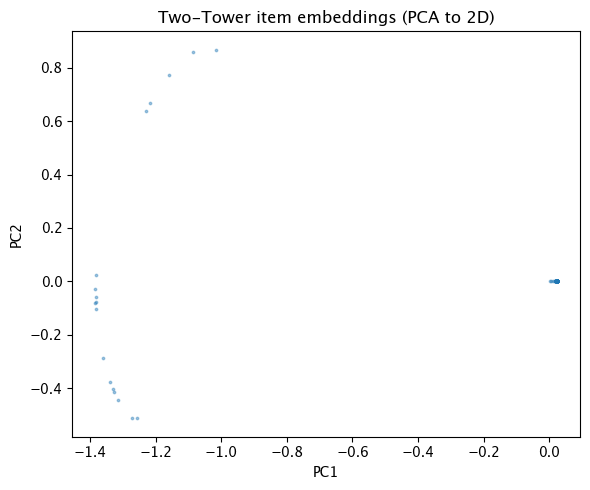

Embedding plot saved to /Users/XuanNguyen/Documents/NUS/DSS5104/dss5104_recommendation_system/data/processed/item_embedding_pca.png


In [13]:
# Embedding visualisation (optional — useful for report)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

tt_ml.eval()
with torch.no_grad():
    all_item_vecs = tt_ml.encode_item(
        torch.arange(n_items_ml, dtype=torch.long).to(DEVICE)
    ).cpu().numpy()

pca   = PCA(n_components=2)
vecs2 = pca.fit_transform(all_item_vecs)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(vecs2[:,0], vecs2[:,1], s=3, alpha=0.4)
ax.set_title('Two-Tower item embeddings (PCA to 2D)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout()
PROC.mkdir(parents=True, exist_ok=True)
plt.savefig(PROC / 'item_embedding_pca.png', dpi=100)
plt.show()
print(f'Embedding plot saved to {PROC / "item_embedding_pca.png"}')